# Reproducing Bayesian DRO experiment

We ran the script given to use by the authors. The goal is to reproduce Figure 1.b. when the data-generating process (DGP) is a truncated normal and when $N=20$. We made the following changes to the script:

- For each replication, we run function `main_Bayesian_DRO` in parallel using the [joblib Parallel](https://joblib.readthedocs.io/en/latest/generated/joblib.Parallel.html) class. We did this to speed up the computation.
- We did not run `main_DRO`, `main_empirical`, `main_Bayesian_DRO_epsilon1`, `main_Bayesian_DRO_epsilon2`, `main_Bayesian_DRO_epsilon3`, and `main_empirical_DRO_Wasserstein`.
- To match Section 4.1, we set `b = 8`, `my_mean = 10`, and `my_std = 10`.
- For each replication, we save a CSV file containing the solution and cost for each epsilon via a pandas dataframe. Each replication file is called `result_k.csv`, where `k` is the replication number.
- Rather than drawing 1 test observation, *we draw 50 test observations*.

You can see the exact differences between the original file and our adapted file by running the `diff` command:

```bash
diff Bayesian_DRO_continuous.py reproduce_bdro_continuous.py
```

***

## Analysing results

In the following notebook, we concatenate all the CSV files together, then group by $\epsilon$.
In each replication $j = 1,\ldots,K$, we are given $N+M$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}, \ldots, \xi_{N+M}^{(j)}$ where the first $N$ points are the training samples and the last $M$ points are the test sample.
For each $\epsilon$ and each replication $j$, we calculate the out-of-sample mean $\mu^{(j)}(\epsilon)$ and variance $v^{(j)}(\epsilon)$ of the objective function under the $M$ test points:
$$
    \mu^{(j)}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M}~\sum_{i=1}^{M}~{G(x^{(j)}(\epsilon), \xi_{i}^{(j)})} \\
    v^{(j)}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M-1}~\sum_{i=1}^{M}~{\left(G(x^{(j)}(\epsilon), \xi_{i}^{(j)}) - \mu^{(j)}(\epsilon)\right)^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution on replication $j = 1,\ldots,K$.
Over all replications, we then calculate $\hat{\mu}_M(\epsilon)$ and $\hat{v}_M(\epsilon)$, where
$\hat{\mu}_M(\epsilon)$ is the mean-of-the-means,
and $\hat{v}_M(\epsilon)$ is the mean-of-the-variances plus the variance-of-the-means.
$$
    \hat{\mu}_M(\epsilon) :=  \frac{1}{K}~\sum_{j=1}^{K}~{ \mu^{(j)}(\epsilon)}, \\
    \hat{v}_M(\epsilon) := \underbrace{\frac{1}{K}~\sum_{j=1}^{K}~{v^{(j)}(\epsilon)}}_{\text{mean-of-the-variances}} + \underbrace{\frac{1}{K-1}~\sum_{j=1}^{K}~{\left( \mu^{(j)}(\epsilon) - \hat{\mu}_M(\epsilon) \right)^2}}_{\text{variance-of-the-means}}.
$$
Note that setting $M=1$ recovers the out-of-sample mean and variance in the usual way.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/more_tests")
assert experiment_dir.exists()
replication = 200
NUM_TEST_OBSERVATIONS = 50
bdro_results_df = pd.concat([pd.read_csv(experiment_dir / f"bdro_result_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon", "test_index"])
wass_results_df = pd.concat([pd.read_csv(experiment_dir / f"wasserstein_result_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon", "test_index"])

In [3]:
# NOTE! the BDRO paper only includes values of epsilon <=0.6
# bdro_results_df = bdro_results_df[bdro_results_df.index.get_level_values("epsilon") <= 0.6]

# group by epsilon and replication to get the mean and variance of each replication $j$
bdro_gb = bdro_results_df.groupby(by=["epsilon", "replication"])
wass_gb = wass_results_df.groupby(by=["epsilon", "replication"])
bdro_mean_df = bdro_gb.mean()
bdro_var_df = bdro_gb.var()
wass_mean_df = wass_gb.mean()
wass_var_df = wass_gb.var()

# get the mean of the means
bdro_mean_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_cost"].mean()
wass_mean_of_means = wass_mean_df.groupby("epsilon")["wasserstein_dro_cost"].mean()

# get the mean of the variances
bdro_mean_of_vars = bdro_var_df.groupby("epsilon")["bayesian_dro_cost"].mean()
wass_mean_of_vars = wass_var_df.groupby("epsilon")["wasserstein_dro_cost"].mean()

# variance of the means
bdro_var_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_cost"].var()
wass_var_of_means = wass_mean_df.groupby("epsilon")["wasserstein_dro_cost"].var()

# mean of the variances + variance of the means (as in the BDRO paper)
bdro_paper_var = bdro_mean_of_vars + bdro_var_of_means
wass_paper_var = wass_mean_of_vars + wass_var_of_means

## M=50: Recovers Figure 1.b.

We can recover the same plot as Bayesian DRO.
First, consider *M=50*.

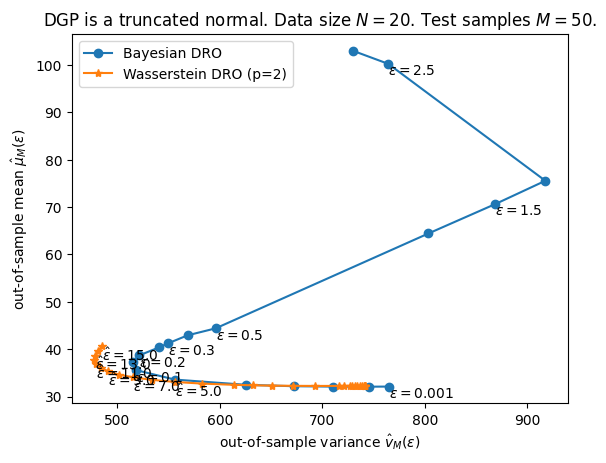

In [4]:
plt.plot(bdro_paper_var, bdro_mean_of_means, marker='o', label="Bayesian DRO")
plt.plot(wass_paper_var, wass_mean_of_means, marker='*', label="Wasserstein DRO (p=2)")

X_LABEL = "out-of-sample variance $\hat{v}_{M}(\epsilon)$"
Y_LABEL = "out-of-sample mean $\hat{\mu}_{M}(\epsilon)$"
plt.title(f"DGP is a truncated normal. Data size $N = 20$. Test samples $M=50$.")
plt.legend()
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)

for i, epsilon in enumerate(bdro_mean_of_means.index.values):
    if i % 2 == 0 and epsilon >= 0.1:
        plt.text(bdro_paper_var.iloc[i], bdro_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
    
    elif epsilon == 0.001:
        plt.text(bdro_paper_var.iloc[i], bdro_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')

for i, epsilon in enumerate(wass_mean_of_means.index.values):
    if i % 2 == 1 and epsilon >= 5:
        plt.text(wass_paper_var.iloc[i], wass_mean_of_means.iloc[i], f"$\hat{{\epsilon}}={epsilon}$", ha='left', va='top')
    

# M=1 : still recovers Figure 1.b.

In [5]:
# only consider 1 test observations
bdro_results_df_1 = bdro_results_df[bdro_results_df.index.get_level_values("test_index") == 0].reset_index(level="test_index", drop=True)
wass_results_df_1 = wass_results_df[wass_results_df.index.get_level_values("test_index") == 0].reset_index(level="test_index", drop=True)

# group by epsilon
bdro_gb_1 = bdro_results_df_1.groupby("epsilon")
wass_gb_1 = wass_results_df_1.groupby("epsilon")

# calculate mean and variance of the single test observation
bdro_mean_1 = bdro_gb_1.mean()["bayesian_dro_cost"]
wass_mean_1 = wass_gb_1.mean()["wasserstein_dro_cost"]
bdro_var_1 = bdro_gb_1.var()["bayesian_dro_cost"]
wass_var_1 = wass_gb_1.var()["wasserstein_dro_cost"]

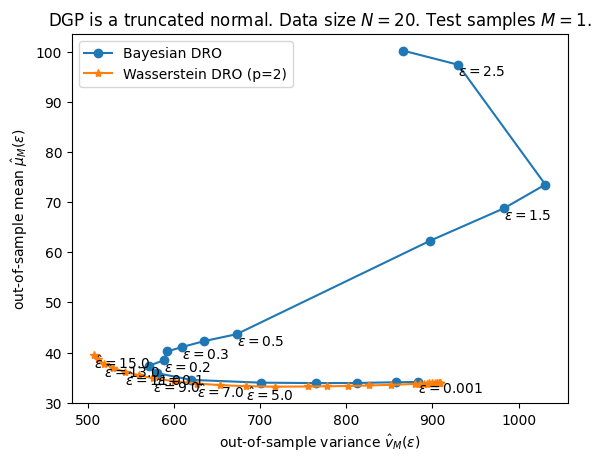

In [6]:
plt.plot(bdro_var_1, bdro_mean_1, marker='o', label="Bayesian DRO")
plt.plot(wass_var_1, wass_mean_1, marker='*', label="Wasserstein DRO (p=2)")

plt.title(f"DGP is a truncated normal. Data size $N = 20$. Test samples $M=1$.")
plt.legend()
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)

for i, epsilon in enumerate(bdro_mean_1.index.values):
    if i % 2 == 0 and epsilon >= 0.1:
        plt.text(bdro_var_1.iloc[i], bdro_mean_1.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
    
    elif epsilon == 0.001:
        plt.text(bdro_var_1.iloc[i], bdro_mean_1.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')

for i, epsilon in enumerate(wass_mean_1.index.values):
    if i % 2 == 1 and epsilon >= 5:
        plt.text(wass_var_1.iloc[i], wass_mean_1.iloc[i], f"$\hat{{\epsilon}}={epsilon}$", ha='left', va='top')
    